In [30]:
# 1.Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
#2. Data Collection

cars=pd.read_csv("Cars.csv")
cars

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [4]:
# 3. Data Understanding

cars.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


In [5]:
cars.shape

(81, 5)

In [6]:
cars.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [7]:
cars.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

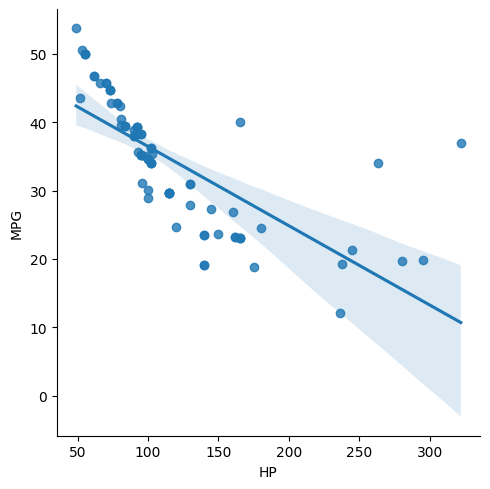

In [11]:
# Linearity
sns.lmplot(data=cars,x="HP",y="MPG")

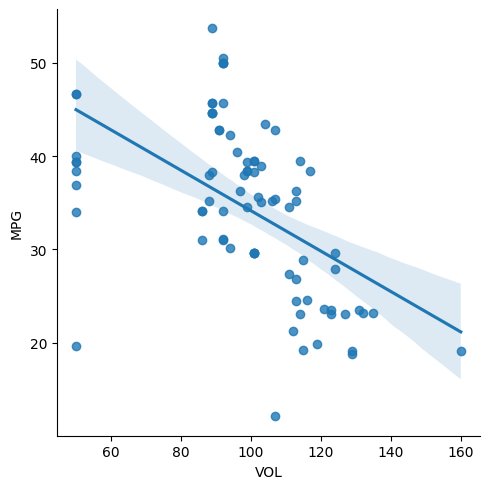

In [12]:
sns.lmplot(data=cars,x="VOL",y="MPG")


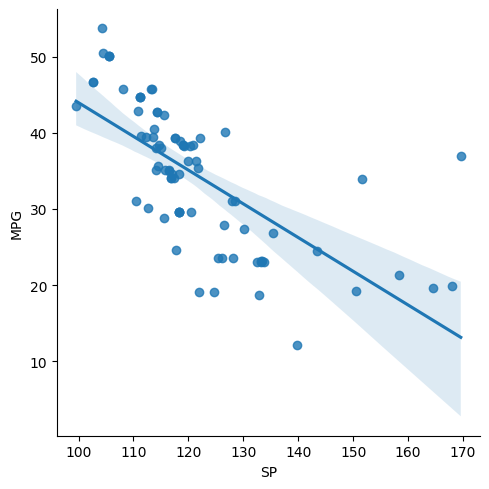

In [13]:
sns.lmplot(data=cars,x="SP",y="MPG")


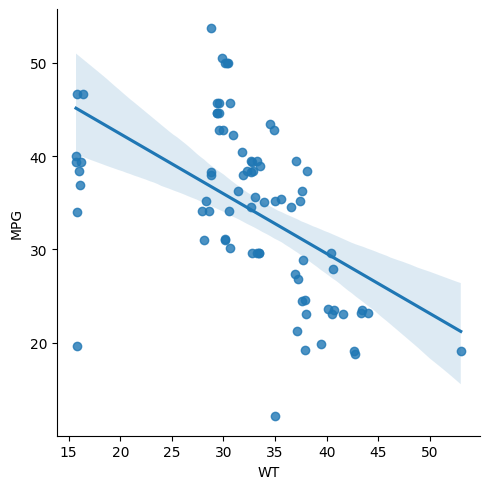

In [14]:
sns.lmplot(data=cars,x="WT",y="MPG")


(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

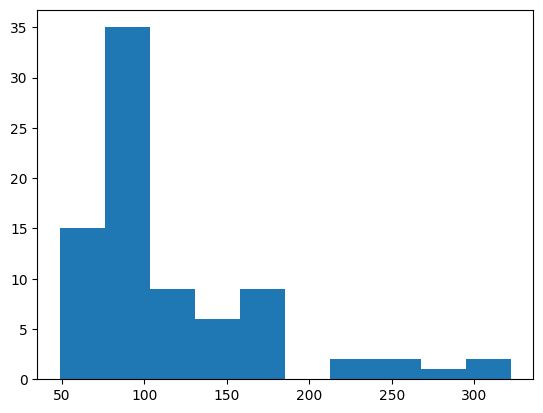

In [15]:
# Normality
plt.hist(cars["HP"])

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

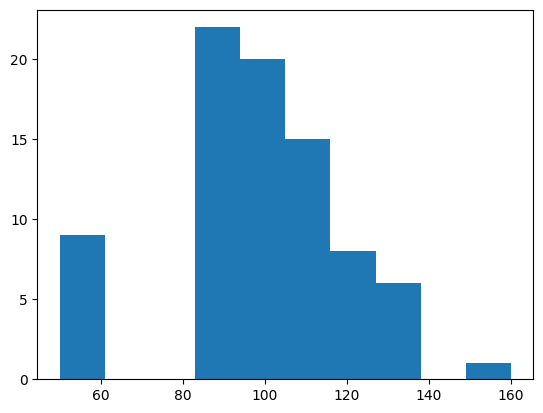

In [16]:
plt.hist(cars["VOL"])

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

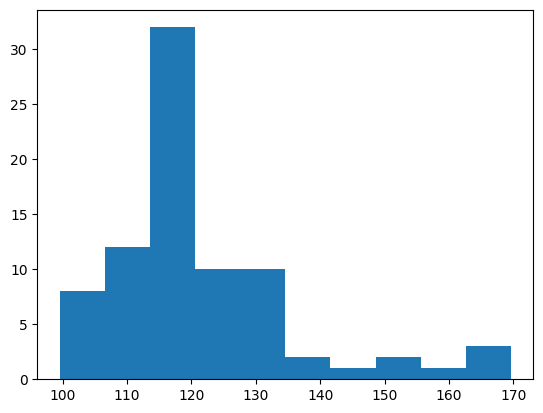

In [17]:
plt.hist(cars["SP"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

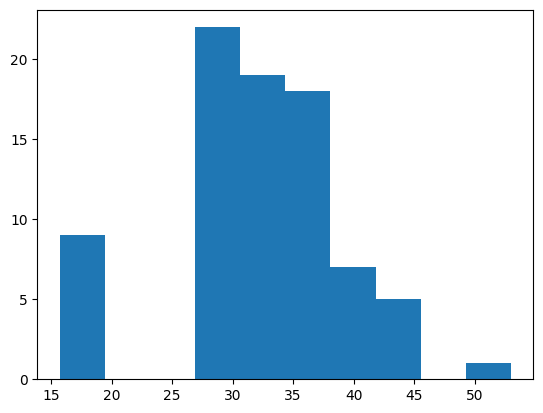

In [18]:
plt.hist(cars["WT"])

In [20]:
# 3.MultiCollinearity

corr_matrix = cars.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

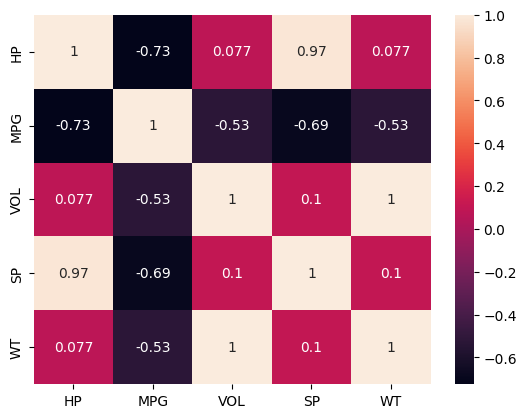

In [22]:
sns.heatmap(corr_matrix,annot=True)

In [23]:
# 4 Data Preparation

cars.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


In [25]:
X=cars[["HP","VOL","SP","WT"]]
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [27]:
y=cars["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

In [29]:
 X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=30,shuffle=True)

In [33]:
# 5. Model Building
linear_model = LinearRegression()

In [34]:
linear_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
#6.Model Training
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred_train = linear_model.predict(X_train)
y_pred_train

array([36.44445148, 37.47536119, 36.82915037, 26.48854933, 35.11080806,
       23.59531565, 32.98717199, 38.54085774, 23.37621241, 37.77734105,
       37.99113285, 37.40517853, 34.4044277 , 35.34897943, 35.35657662,
       42.71261015, 47.0645295 , 37.94370626, 31.91744798, 40.60046874,
       21.94215681, 14.47577786, 36.79378982, 33.10710898, 33.82785986,
       41.25793603, 28.91236188, 37.12565915, 34.65356319, 41.16185921,
       39.11542129, 21.34715799, 41.21841858, 48.318603  , 42.81666136,
       24.04565986, 22.77009777, 38.66854574, 41.64841038, 40.99188606,
       24.40779667, 38.47309056, 30.18915566, 28.99159845, 25.04307084,
       41.09035265, 37.33448786, 28.50728044, 19.25938969, 33.16827817,
       37.37097086, 47.83981458, 35.03566486, 42.2016399 , 33.98102639,
       48.42882143, 28.4545498 , 41.61967093, 39.22701246, 39.98970372,
       28.41396752, 36.09612381, 16.55880068, 38.28532164])

In [39]:
# Test data
y_pred_test = linear_model.predict(X_test)
y_pred_test

array([37.21744799, 18.22243365, 41.15808304, 30.70180148, 47.96782924,
       26.08852078, 33.16283454, 28.62727019, 40.05445132, 35.54302235,
       36.83137625, 41.51001875, 35.927537  , 26.43219977, 41.6880245 ,
       24.79829869, 35.44096623])

In [41]:
error = y_train-y_pred_train
error

39   -5.430321
48   -6.461230
21    5.999329
66   -3.385378
58   -4.978885
        ...   
12   -0.635610
78    5.586032
45   -1.534625
80   -4.457538
37   -4.214653
Name: MPG, Length: 64, dtype: float64

In [42]:
error = y_test-y_pred_test
error

32    -0.931992
73     0.863907
10     3.494751
70   -11.023295
8     -1.251275
64    -2.483362
51    -3.532899
55    -0.771018
24    -1.743845
44     0.100535
34     2.700256
4      8.994213
29    -0.523345
63    -2.916283
1      8.325377
68    -1.695127
56    -4.327382
Name: MPG, dtype: float64

In [43]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [44]:
mean_absolute_error(y_train,y_pred_train)

3.3748042232398454

In [50]:
mean_absolute_error(y_test,y_pred_test)

3.275227179780683

In [51]:
mean_squared_error(y_train,y_pred_train)

19.19823666398487

In [46]:
mean_squared_error(y_test,y_pred_test)

20.416377600355403

In [47]:
root_mean_squared_error(y_train,y_pred_train)

4.3815792431479395

In [49]:
root_mean_squared_error(y_test,y_pred_test)

4.518448583347541

In [66]:
r2_score(y_train,y_pred_train)

0.7528081609421929

In [52]:
import statsmodels.formula.api as smf

In [55]:
stat_linear_model = smf.ols(formula = "MPG ~ HP+VOL+SP+WT",data = cars).fit()

In [62]:
y_pred_stat_train = stat_linear_model.predict(X_train)

In [60]:
y_pred_stat_test = stat_linear_model.predict(X_test)

In [65]:
stat_linear_model.rsquared

np.float64(0.7705372737359842)